In [9]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")


In [10]:
NORMAL_FILES = [
    "data/cleaned_combined.csv",
]

TARGET_COL = "Processor_% Processor Time"

LEAKY_COLS = {
    "Processor_% Idle Time",
    "Processor_% User Time",
    "Processor_% Privileged Time",
    "Processor_% DPC Time",
    "Processor_% Interrupt Time",
    "Processor_% C1 Time",
    "Processor_% C2 Time",
    "Processor_% C3 Time",
}

FEATURE_COLS = [
    "Processor_Interrupts/sec",
    "Processor_DPCs Queued/sec",
    "Processor_DPC Rate",
    "Process_IO Read Bytes/sec",
    "Process_IO Write Bytes/sec",
    "Process_IO Data Operations/sec",
    "Process_IO Read Operations/sec",
    "Process_Working Set",
    "Process_Working Set - Private",
    "Process_Page Faults/sec",
    "Process_Thread Count",
    "Process_Handle Count",
    "Memory_Page Faults/sec",
    "Memory_Demand Zero Faults/sec",
    "Memory_Available MBytes",
    "Memory_% Committed Bytes In Use",
    "Memory_Cache Faults/sec",
    "Memory_Transition Faults/sec",
    "Memory_Pages Input/sec",
    "Memory_Pages Output/sec",
    "Memory_Pages/sec",
]

In [11]:
TEST_SIZE   = 0.25
RANDOM_SEED = 42
PLOT_SAMPLE = 2000
RESIDUAL_BINS = 60

In [12]:
def strip_host(col: str) -> str:
    return re.sub(r"^\\\\[^\\]+\\", "", col).strip()


def load_pdh_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df.columns = [strip_host(c) if i > 0 else "ts" for i, c in enumerate(df.columns)]
    df = df.drop(columns=["ts"], errors="ignore")
    df = df.replace(" ", np.nan)
    return pd.to_numeric(df.stack(), errors="coerce").unstack()


def load_data() -> tuple:
    data = pd.read_csv("data/cleaned_combined.csv", low_memory=False)
    common = [
        c for c in data.columns
        if c not in ["timestamp", "os", "label", "source_file"]
]
    data = data.dropna(thresh=int(0.2 * len(common)))
    return data, common

In [13]:
def build_features(data: pd.DataFrame, common: list) -> tuple:
    feat_cols = [c for c in FEATURE_COLS if c in common]
    if not feat_cols:
        feat_cols = [c for c in common if c != TARGET_COL]
    X = data[feat_cols].fillna(0)
    y = data[TARGET_COL].fillna(0)
    mask = y.between(0, 100)
    return X[mask], y[mask], feat_cols

In [14]:
def plot_actual_vs_predicted(y_test: np.ndarray, y_pred: np.ndarray):
    sample_idx = np.random.choice(len(y_test), size=min(PLOT_SAMPLE, len(y_test)), replace=False)
    y_s = y_test[sample_idx]
    p_s = y_pred[sample_idx]

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(y_s, p_s, alpha=0.3, s=12, color="#378ADD", edgecolors="none")
    lo = min(y_s.min(), p_s.min())
    hi = max(y_s.max(), p_s.max())
    ax.plot([lo, hi], [lo, hi], color="#E24B4A", linewidth=1.5, linestyle="--", label="Perfect fit")
    ax.set_xlabel("Actual % Processor Time")
    ax.set_ylabel("Predicted % Processor Time")
    ax.set_title("Actual vs Predicted — CPU Usage")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [15]:
def plot_residuals(y_test: np.ndarray, y_pred: np.ndarray):
    residuals = y_test - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sample_idx = np.random.choice(len(y_pred), size=min(PLOT_SAMPLE, len(y_pred)), replace=False)
    axes[0].scatter(y_pred[sample_idx], residuals[sample_idx],
                    alpha=0.3, s=12, color="#7F77DD", edgecolors="none")
    axes[0].axhline(0, color="#E24B4A", linewidth=1.5, linestyle="--")
    axes[0].set_xlabel("Predicted % Processor Time")
    axes[0].set_ylabel("Residual")
    axes[0].set_title("Residuals vs Predicted")

    axes[1].hist(residuals, bins=RESIDUAL_BINS, color="#1D9E75", edgecolor="white", linewidth=0.4)
    axes[1].axvline(0, color="#E24B4A", linewidth=1.5, linestyle="--")
    axes[1].set_xlabel("Residual")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Residual Distribution")

    plt.tight_layout()
    plt.show()

Loading cleaned dataset ...
Samples: 29146   Features: 21
Target range: 0.00 - 100.00   Mean: 25.00
LINEAR REGRESSION — EVALUATION
MAE  : 4.6430
RMSE : 7.8980
R2   : 0.7691

Top 10 features by absolute coefficient:
                       feature  coefficient
              Memory_Pages/sec   150.106408
        Memory_Pages Input/sec   -96.454987
Process_IO Data Operations/sec    89.302037
Process_IO Read Operations/sec   -88.906845
       Memory_Pages Output/sec   -57.964558
          Process_Thread Count    10.735489
      Processor_Interrupts/sec    10.730279
     Processor_DPCs Queued/sec    -8.762321
        Memory_Page Faults/sec     5.995852
          Process_Handle Count    -4.230755


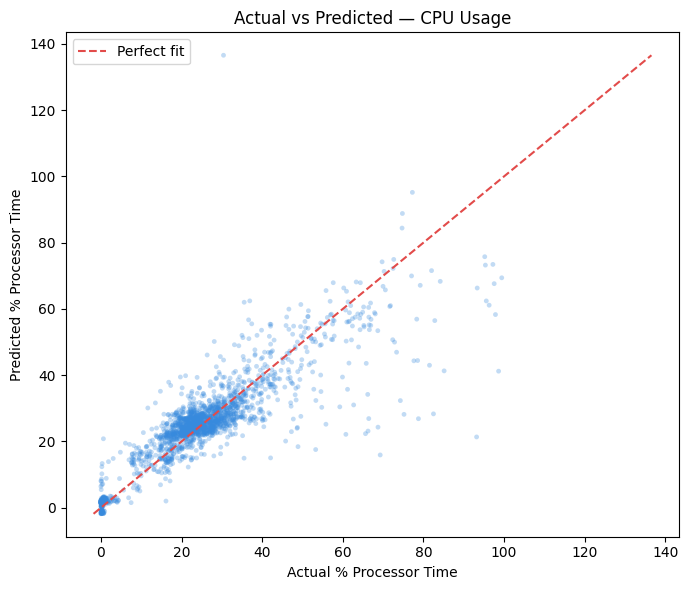

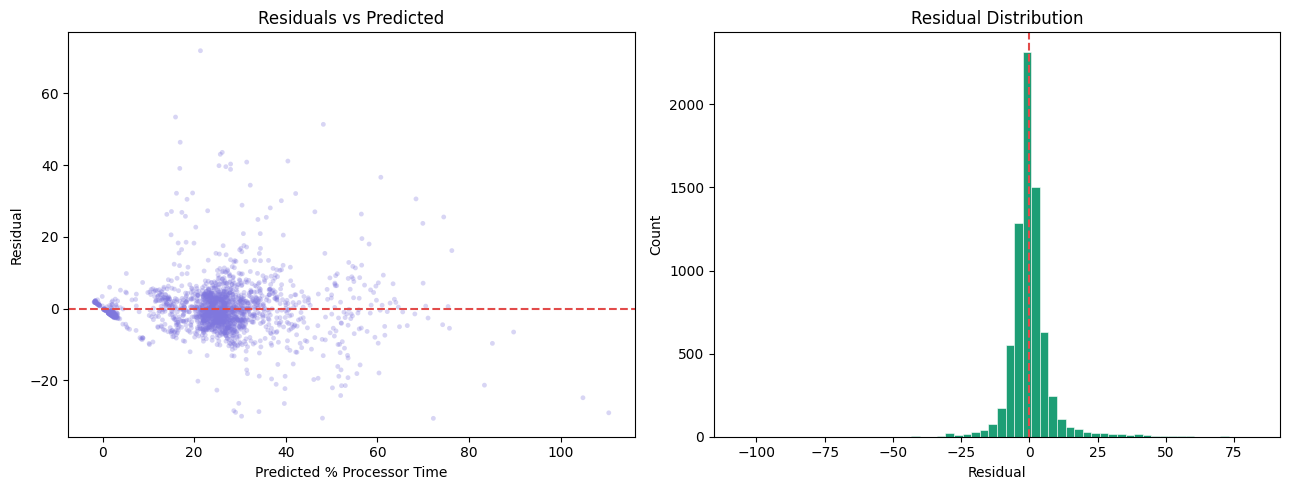

In [16]:
print("Loading cleaned dataset ...")
data, common = load_data()

X, y, feat_cols = build_features(data, common)
print(f"Samples: {len(y)}   Features: {len(feat_cols)}")
print(f"Target range: {y.min():.2f} - {y.max():.2f}   Mean: {y.mean():.2f}")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

model = LinearRegression()
model.fit(X_tr_s, y_tr)

y_pred = model.predict(X_te_s)

mae  = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
r2   = r2_score(y_te, y_pred)

print("=" * 45)
print("LINEAR REGRESSION — EVALUATION")
print("=" * 45)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print("=" * 45)

coef_df = pd.DataFrame({
    "feature": feat_cols,
    "coefficient": model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("\nTop 10 features by absolute coefficient:")
print(coef_df.head(10).to_string(index=False))

y_te_arr   = y_te.to_numpy()
y_pred_arr = y_pred

plot_actual_vs_predicted(y_te_arr, y_pred_arr)
plot_residuals(y_te_arr, y_pred_arr)